**Descrição do projeto**

Rusty Bargain é um serviço de venda de carros usados que está desenvolvendo um aplicativo para atrair novos clientes. Nesse aplicativo, você pode descobrir rapidamente o valor de mercado do seu carro. Você tem acesso a dados históricos, especificações técnicas, versões de acabamento e preços. Você precisa construir o modelo para determinar o valor.

Rusty Bargain está interessado em:

- a qualidade da predição;
- a velocidade da predição;
- o tempo necessário para o treinamento

**Características**

DateCrawled — data em que o perfil foi baixado do banco de dados
VehicleType — tipo de carroçaria do veículo
RegistrationYear — ano de matrícula do veículo
Gearbox — tipo de caixa de transmissão
Power — potência (hp)
Model — modelo do veículo
Mileage — quilometragem (medida em km devido às especificidades regionais do conjunto de dados)
RegistrationMonth — mês de registro do veículo
FuelType — tipo de combustível
Brand — marca do veículo
NotRepaired — veículo reparado ou não
DateCreated — data de criação do perfil
NumberOfPictures — número de fotos do veículo
PostalCode — código postal do proprietário do perfil (usuário)
LastSeen — data da última atividade do usuário

**Objetivo**

Price — preço (Euro)

**Preparação de Dados**

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
import sklearn.preprocessing
from sklearn.preprocessing import StandardScaler
import math
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from IPython.display import display
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_car = pd.read_csv('car_data.csv')

In [3]:
df_car

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354364,21/03/2016 09:50,0,NaN,2005,manual,0,colt,150000,7,petrol,mitsubishi,yes,21/03/2016 00:00,0,2694,21/03/2016 10:42
354365,14/03/2016 17:48,2200,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,14/03/2016 00:00,0,39576,06/04/2016 00:46
354366,05/03/2016 19:56,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no,05/03/2016 00:00,0,26135,11/03/2016 18:17
354367,19/03/2016 18:57,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no,19/03/2016 00:00,0,87439,07/04/2016 07:15


In [4]:
df_car.describe()

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


In [5]:
df_car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

In [6]:
#Verificando valores ausentes
df_car.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Mileage                  0
RegistrationMonth        0
FuelType             32895
Brand                    0
NotRepaired          71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

In [7]:
#Preenchendo valores ausentes
df_car = df_car.fillna({'VehicleType': 'unknown'})
df_car = df_car.fillna({'Gearbox': 'unknown'})
df_car = df_car.fillna({'Model': 'unknown'})
df_car = df_car.fillna({'FuelType': 'unknown'})
df_car = df_car.fillna({'NotRepaired': 'unknown'})
print(df_car.isna().sum())  

DateCrawled          0
Price                0
VehicleType          0
RegistrationYear     0
Gearbox              0
Power                0
Model                0
Mileage              0
RegistrationMonth    0
FuelType             0
Brand                0
NotRepaired          0
DateCreated          0
NumberOfPictures     0
PostalCode           0
LastSeen             0
dtype: int64


In [8]:
#Renomeando as colunas maiúsculas para minúsculas
df_car.columns = df_car.columns.str.lower()
df_car                          #Verificação das colunas

,datecrawled,price,vehicletype,registrationyear,gearbox,power,model,mileage,registrationmonth,fueltype,brand,notrepaired,datecreated,numberofpictures,postalcode,lastseen
0,24/03/2016 11:52,480,unknown,1993,manual,0,golf,150000,0,petrol,volkswagen,unknown,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,unknown,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,unknown,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354364,21/03/2016 09:50,0,unknown,2005,manual,0,colt,150000,7,petrol,mitsubishi,yes,21/03/2016 00:00,0,2694,21/03/2016 10:42
354365,14/03/2016 17:48,2200,unknown,2005,unknown,0,unknown,20000,1,unknown,sonstige_autos,unknown,14/03/2016 00:00,0,39576,06/04/2016 00:46
354366,05/03/2016 19:56,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no,05/03/2016 00:00,0,26135,11/03/2016 18:17
354367,19/03/2016 18:57,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no,19/03/2016 00:00,0,87439,07/04/2016 07:15


In [9]:
print(df_car['price'].unique())

[  480 18300  9800 ... 12395 18429 10985]


<Axes: >

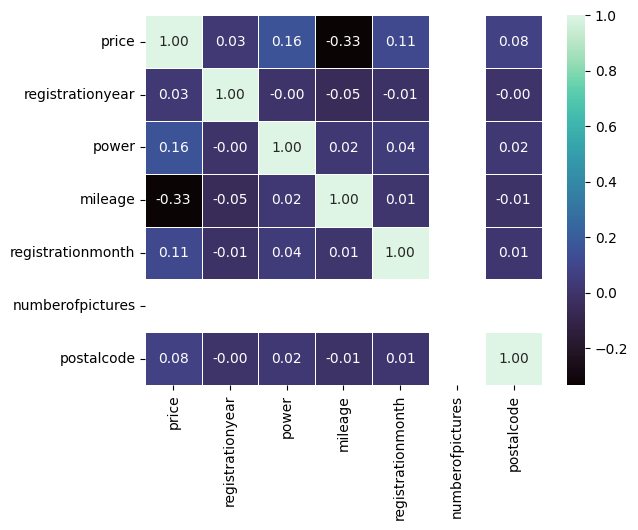

In [10]:
#Correlação Heatmap
numeric_cols = df_car.select_dtypes(include=np.number)
numeric_cols = numeric_cols.corr()
sns.heatmap(numeric_cols, annot=True, cmap='mako', fmt='.2f', linewidths=0.5)

**Conclusão**

A quilometragem é o fator mais fortemente (negativamente) correlacionado com o preço do veículo, enquanto a potência mostra uma correlação positiva moderada. As demais variáveis apresentadas na matriz têm pouca ou nenhuma relação linear forte com o preço.

In [11]:
df_car = df_car.drop(columns=['datecrawled', 'datecreated', 'numberofpictures', 'lastseen'])

In [12]:
df_car = df_car[df_car['registrationyear'] < 2025]
df_car = df_car[df_car['registrationyear'] > 1900]
df_car = df_car[df_car['power'] != 0]
df_car.reset_index(drop=True, inplace=True)

In [13]:
df_car['model'] = pd.Categorical(df_car['model'])
df_car['gearbox'] = pd.Categorical(df_car['gearbox'])
df_car['fueltype'] = pd.Categorical(df_car['fueltype'])
df_car['vehicletype'] = pd.Categorical(df_car['vehicletype'])
print(df_car.dtypes)

price                   int64
vehicletype          category
registrationyear        int64
gearbox              category
power                   int64
model                category
mileage                 int64
registrationmonth       int64
fueltype             category
brand                  object
notrepaired            object
postalcode              int64
dtype: object


In [14]:
df_car['brand'] = df_car['brand'].astype('category')
df_car['notrepaired'] = df_car['notrepaired'].astype('category')
print(df_car.dtypes)

price                   int64
vehicletype          category
registrationyear        int64
gearbox              category
power                   int64
model                category
mileage                 int64
registrationmonth       int64
fueltype             category
brand                category
notrepaired          category
postalcode              int64
dtype: object


In [15]:
df_car = pd.get_dummies(df_car, dtype=int)

In [16]:
#Normalizando os dados
X = df_car.drop(columns=['price'])
y = df_car['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
print("Dados de Treino Originais:")
print(X_train)
print("Dados de Treino Normalizados (StandardScaler):")
print(X_train_scaled_df)

print("Dados de Teste Originais:")
print(X_test)
print("Dados de Teste Normalizados (StandardScaler):")
print(X_test_scaled_df)

Dados de Treino Originais:
        registrationyear  power  mileage  registrationmonth  postalcode  \
211305              2011     84   150000                 11       27367   
113088              1999    204   150000                  1       76571   
48687               1995    110   150000                  4       57258   
68813               2004    170   150000                  1       45768   
136032              2002    109   150000                  7       89522   
...                  ...    ...      ...                ...         ...   
119879              2001    170   150000                  4       60435   
259178              2002     75   150000                  7       48155   
131932              2002     55   150000                  9       30625   
146867              2009    150   150000                  6       64283   
121958              2006    200   150000                 10       80687   

        vehicletype_bus  vehicletype_convertible  vehicletype_coupe  \
2

**Treinamento do modelo**

In [17]:
#Treine modelos
X = df_car.drop(columns=['price'])
y = df_car['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Tamanho do conjunto de treino (y_train): {y_train.shape}")
print(f"Tamanho do conjunto de teste (y_test): {y_test.shape}")

Tamanho do conjunto de treino (X_train): (251280, 318)
Tamanho do conjunto de teste (X_test): (62820, 318)
Tamanho do conjunto de treino (y_train): (251280,)
Tamanho do conjunto de teste (y_test): (62820,)


In [18]:
#Criar uma instância do modelo de Regressão Linear
model = LinearRegression()

#Treinar o modelo usando os dados de treino
model.fit(X_train, y_train)

print("Modelo de Regressão Linear treinado com sucesso!")
print(f"Coeficientes do modelo: {model.coef_}")
print(f"Intercepto do modelo: {model.intercept_}")

Modelo de Regressão Linear treinado com sucesso!
Coeficientes do modelo: [ 2.73385768e+02  9.37321933e-01 -3.77689126e-02  1.24261968e+01
  5.48863457e-03 -5.46184477e+01  1.84265580e+03  1.18616169e+03
 -3.54597170e+02  3.23478884e+01 -4.55352012e+02  1.41339549e+03
 -3.62047625e+03  1.04830556e+01  7.29373767e+02 -4.38159120e+02
 -2.91214655e+02 -1.21062138e+03 -1.36860483e+03 -2.22098192e+03
 -2.12202949e+03  7.76011675e+02 -6.84877104e+02  5.21604243e+02
  2.01262102e+03 -8.29874033e+02  4.83383427e+03  2.47048822e+01
 -1.26558902e+03 -1.28542189e+02  8.57773421e+02  2.74348662e+03
 -3.66000303e+02 -2.14547239e+03  6.71341746e+02  5.29568201e+03
 -3.84935058e-03 -2.19732439e+03 -7.35979960e+02 -3.86499092e+02
  1.54907956e+03  7.77594849e+02  1.18208955e+03  1.46128632e+03
 -2.30829398e+03 -1.42750986e+03 -1.38899491e+03  4.57722840e+03
 -1.26837989e+03  5.34148182e+01 -3.92479290e+03  8.89385027e+02
 -2.85368590e+03  7.95923404e+02 -2.40568742e+03  6.23897776e+02
  1.28797181e+03 

In [19]:
y_pred = model.predict(X_test)

print(f"Primeiras 5 previsões:\n{y_pred[:5]}")
print(f"Primeiros 5 valores reais (y_test):\n{y_test.head().values}")

Primeiras 5 previsões:
[ 7394.59620086  6939.52462603 11858.09506793  5260.07302755
  3217.02344747]
Primeiros 5 valores reais (y_test):
[ 5500  4900 11200  5500   999]


In [20]:
#Calcular o Erro Quadrático Médio (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")

#Calcular o R-quadrado (R2 Score)
r2 = r2_score(y_test, y_pred)
print(f"Coeficiente de Determinação (R-quadrado): {r2:.2f}")

Erro Quadrático Médio (MSE): 8050090.19
Coeficiente de Determinação (R-quadrado): 0.62


In [21]:
#Treinando modelo de Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

print("Modelo Random Forest treinado com sucesso!")

Modelo Random Forest treinado com sucesso!


In [22]:
y_pred_rf = model_rf.predict(X_test)

print(f"Primeiras 5 previsões do Random Forest:\n{y_pred_rf[:5]}")
print(f"Primeiros 5 valores reais (y_test):\n{y_test.head().values}")

Primeiras 5 previsões do Random Forest:
[5906.6        7295.26       9940.94       2905.65952381  848.3       ]
Primeiros 5 valores reais (y_test):
[ 5500  4900 11200  5500   999]


In [23]:
mae_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Mean Absolute Error (MAE) do Random Forest: {mae_rf:.2f}")
print(f"R-squared (R2) do Random Forest: {r2_rf:.2f}")

Mean Absolute Error (MAE) do Random Forest: 2708082.58
R-squared (R2) do Random Forest: 0.87


In [24]:
#Treinando modelo de Regressão de Árvores
model_dt = DecisionTreeRegressor(max_depth=10, random_state=42)
model_dt.fit(X_train, y_train)

print("Modelo Decision Tree Regressor treinado com sucesso!")

Modelo Decision Tree Regressor treinado com sucesso!


In [25]:
y_pred_dt = model_dt.predict(X_test)

print(f"Primeiras 5 previsões do Decision Tree:\n{y_pred_dt[:5]}")
print(f"Primeiros 5 valores reais (y_test):\n{y_test.head().values}")

Primeiras 5 previsões do Decision Tree:
[4413.35820896 6048.20779221 9292.19771863 3544.35020804 1019.95286439]
Primeiros 5 valores reais (y_test):
[ 5500  4900 11200  5500   999]


In [26]:
mae_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Mean Absolute Error (MAE) do Decision Tree: {mae_dt:.2f}")
print(f"R-squared (R2) do Decision Tree: {r2_dt:.2f}")

Mean Absolute Error (MAE) do Decision Tree: 4343330.04
R-squared (R2) do Decision Tree: 0.79


In [27]:
#Treinando modelo de Gradient Boosting
model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model_gb.fit(X_train, y_train)

print("Modelo Gradient Boosting Regressor treinado com sucesso!")

Modelo Gradient Boosting Regressor treinado com sucesso!


In [28]:
y_pred_gb = model_gb.predict(X_test)

print(f"Primeiras 5 previsões do Gradient Boosting:\n{y_pred_gb[:5]}")
print(f"Primeiros 5 valores reais (y_test):\n{y_test.head().values}")

Primeiras 5 previsões do Gradient Boosting:
[ 5485.24709994  6375.08827418 10427.08224543  3067.40741549
  1395.97831362]
Primeiros 5 valores reais (y_test):
[ 5500  4900 11200  5500   999]


In [29]:
mae_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Mean Absolute Error (MAE) do Gradient Boosting: {mae_gb:.2f}")
print(f"R-squared (R2) do Gradient Boosting: {r2_gb:.2f}")

Mean Absolute Error (MAE) do Gradient Boosting: 4041179.82
R-squared (R2) do Gradient Boosting: 0.81


**Análise do modelo**

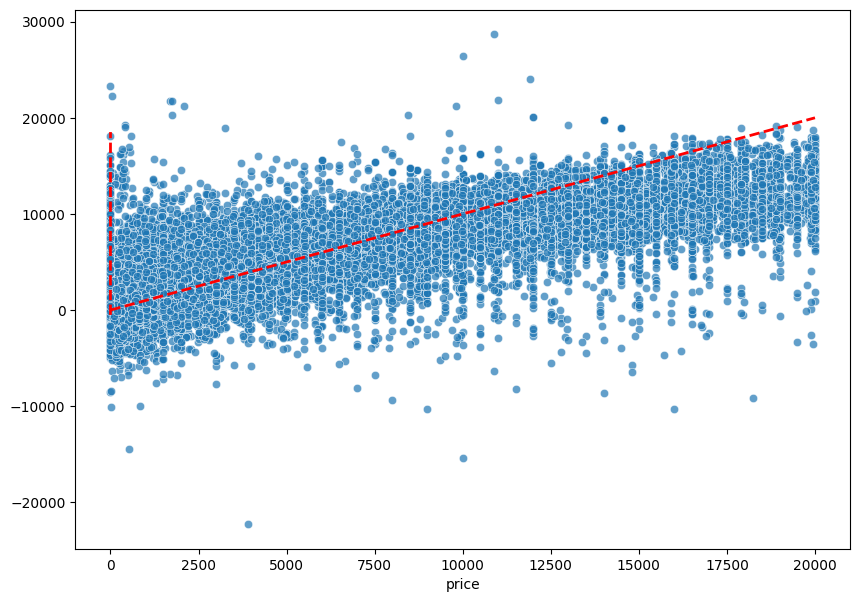

In [30]:
#Calcular as métricas para incluir no título/legenda, se desejar
mse_valid = mean_squared_error(y_test, y_pred_dt)
rmse_valid = mean_squared_error(y_test, y_pred_rf) # REQM
r2_valid = r2_score(y_test, y_pred_gb)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7) # Plotar os pontos de dados
plt.plot([y_pred_dt.min(), y_pred_dt.max()], [y_pred_rf.min(), y_pred_rf.max()], [y_pred_gb.min(), y_pred_gb.max()], color='red', linestyle='--', lw=2, label='Linha Ideal (Previsão = Real)') # Linha de referência ideal

**Conclusão**

Existe uma relação positiva entre as duas variáveis representadas no gráfico, onde uma tende a aumentar à medida que a outra aumenta.
No entanto, essa relação não é perfeitamente linear e a variabilidade dos dados aumenta com o "preço".
Há também um comportamento peculiar para preços muito baixos.